# Flight Delay and Cancellation Analysis (Part 1)

This notebook contains one consolidated and functional Part 1 workflow.
It merges the previous organized narrative with the currently working implementation.

## Notebook Goals

- Build a reliable preprocessing and feature-engineering pipeline.
- Perform exploratory analysis and dimensionality reduction.
- Run hypothesis testing to statistically validate feature relevance.
- Save intermediate and final checkpoints for reproducibility.

## Execution Phases

1. Problem formulation
2. Data loading and cleansing
3. Feature engineering and transformation
4. EDA and dimensionality reduction
5. Hypothesis testing and artifact export

> Tip: set `NROWS = 10000` for a quick run, or `NROWS = None` for the full dataset.


In [1]:
from pathlib import Path
import sys

import pandas as pd

# Resolve project root dynamically to avoid hardcoded absolute paths.
project_root = Path.cwd().resolve()
while project_root != project_root.parent and project_root.name != "DataScience_IA":
    project_root = project_root.parent

if project_root.name != "DataScience_IA":
    raise FileNotFoundError("Could not locate project root folder 'DataScience_IA'.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Project_Code.PythonCode.DataPreProcessor.FlightDataCleaner import FlightDataCleaner
from Project_Code.PythonCode.FeatureEngeneering.FlightFeatureEngineer import FlightFeatureEngineer
from Project_Code.PythonCode.EDA.FlightEDA import FlightEDA
from Project_Code.PythonCode.Util.DataVisualization import DataVisualization
from Project_Code.PythonCode.Util.DataLoader import DataLoader
from Project_Code.PythonCode.HypothesisTesting.HypothesisTester import HypothesisTester


dataset_path = project_root / "DataSet" / "flights_sample_3m.csv"
output_dir = project_root / "Output_Files"
output_dir.mkdir(parents=True, exist_ok=True)

# DataLoader now auto-downloads the dataset if this local CSV is missing.
# Keep dataset_path as the target location where the CSV should exist/be created.

# Runtime configuration.
NROWS = 10000
TEST_SIZE = 0.2
RANDOM_STATE = 42

print("Project root:", project_root)
print("Dataset path:", dataset_path)
print("Output dir:", output_dir)


C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\Lenovo\Desktop\DataScience_IA
Dataset path: C:\Users\Lenovo\Desktop\DataScience_IA\DataSet\flights_sample_3m.csv
Output dir: C:\Users\Lenovo\Desktop\DataScience_IA\Output_Files


## Phase 1 - Problem Formulation

This project studies domestic US flight operations (2019-2023) with two predictive targets and one exploratory objective.

### Main Analytical Objectives

1. **Regression task**: predict `ARR_DELAY` (arrival delay in minutes).
2. **Classification task**: predict `DELAY_CLASS` after feature engineering.
3. **Exploratory objective**: identify operational patterns and group-level behavior.

### Leakage-Aware Perspective

A key requirement is to avoid data leakage by excluding post-departure and post-arrival signals during modeling preparation.
This ensures that engineered features represent information realistically available before departure.


In [2]:
phase1_summary = pd.DataFrame(
    {
        "Objective": ["Regression", "Classification", "Pattern Discovery"],
        "Target / Focus": ["ARR_DELAY", "DELAY_CLASS", "EDA + Reduction"],
    }
)
phase1_summary


,Objective,Target / Focus
0,Regression,ARR_DELAY
1,Classification,DELAY_CLASS
2,Pattern Discovery,EDA + Reduction


## Phase 2 - Data Loading and Cleansing

This phase standardizes the raw data preparation pipeline and persists an intermediate checkpoint.

### Steps

1. Load raw data from CSV.
2. Clean raw records (cancelled/diverted filtering, leakage column removal, outlier treatment, null handling).
3. Split cleaned data into train/test sets.
4. Validate resulting cleaned dataset dimensions and quality.


In [3]:
# STEP 1: Load raw data
print("Loading raw dataset...")
loader = DataLoader(str(dataset_path), test_size=TEST_SIZE, random_state=RANDOM_STATE)
df_raw = pd.read_csv(dataset_path, nrows=NROWS)
print(f"Raw data loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")


Loading raw dataset...
Raw data loaded: 10000 rows × 32 columns


In [4]:
# STEP 2: Clean the dataset
cleaner = FlightDataCleaner(df=df_raw)
df_clean = cleaner.load_and_clean(nrows=None, random_state=RANDOM_STATE)
df_clean.to_csv("../../DataSet/cleaned_flight_data.csv", index=False)

df_clean = cleaner.classify_target()
print("Clean shape:", df_clean.shape)
print("Numeric missing values after cleaning:", int(df_clean.select_dtypes(include=["number"]).isnull().sum().sum()))
df_clean.head(3)


INICIANDO PROCESSO DE LIMPEZA DE DADOS

1. A usar DataFrame fornecido no construtor...
   ✓ Dataset carregado: 10000 linhas × 32 colunas

2. A remover voos cancelados e desviados...
   ✓ Removidos 270 voos (cancelados/desviados)

4. A remover nulos na variável alvo...
   ✓ Removidas 0 linhas com ARR_DELAY nulo

5. A converter atrasos negativos para zero...
   ✓ 6324 valores negativos de ARR_DELAY convertidos para 0

6. A balancear dataset (atrasos positivos vs zeros)...
   ✓ Dataset balanceado: 3212 atrasos positivos + 3212 zeros

7. A tratar outliers e missing values...
   ✓ DISTANCE: 359 outliers tratados
   ✓ CRS_ELAPSED_TIME: 307 outliers tratados
   ✓ 23265 missing values imputados (média)

8. A remover colunas redundantes...
   ✓ Removidas 5 colunas redundantes

LIMPEZA CONCLUÍDA!
Dimensão final: 6424 linhas × 24 colunas
Redução: 3576 linhas removidas (35.8%)

Clean shape: (6424, 25)
Numeric missing values after cleaning: 0


,FL_DATE,AIRLINE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,...,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,DELAY_CLASS
0,2021-01-09,SkyWest Airlines Inc.,OO,DEN,SUN,1150,1149.0,-1.0,29.0,1218.0,...,124.0,136.0,103.0,557.0,23.776962,4.201581,12.968944,0.23546,23.741389,On-time
1,2020-02-23,United Air Lines Inc.,UA,MFE,IAH,720,710.0,-10.0,12.0,722.0,...,75.0,63.0,47.0,316.0,23.776962,4.201581,12.968944,0.23546,23.741389,On-time
2,2019-02-19,Southwest Airlines Co.,WN,ABQ,SAN,630,628.0,-2.0,20.0,648.0,...,120.0,116.0,93.0,628.0,23.776962,4.201581,12.968944,0.23546,23.741389,On-time


In [5]:
# STEP 3: Split cleaned data into train/test sets
loader.data = df_clean
data_train, data_test, target_train, target_test = loader.split_data(target_column='ARR_DELAY')

print("Train shape:", data_train.shape)
print("Test shape:", data_test.shape)
print("Target train shape:", target_train.shape if target_train is not None else None)
print("Target test shape:", target_test.shape if target_test is not None else None)



Data split completed: 5139 train × 1285 test
Train shape: (5139, 24)
Test shape: (1285, 24)
Target train shape: (5139,)
Target test shape: (1285,)


## Phase 2 - Exploratory Data Analysis and Dimensionality Reduction

This section combines analytical diagnostics with visual diagnostics.
In this phase we will conduct EDA in which we gather insights on the data. We aim to conduct descriptive statistics through statistical techniques and deriving graphs for visualization. As well as performing dimension reduction to get a general understanding of the data.

This phase will therefore be divided into 2 categories:

### Analytical diagnostics

- Distribution and descriptive summaries
- Variable ranges and correlation structure
- Data quality checks

### Dimensionality reduction

- PCA for linear structure
- UMAP (or t-SNE fallback) for non-linear structure


INICIANDO ANALISE EXPLORATORIA (EDA)
INICIANDO EDA ANALITICA

ESTATISTICAS DESCRITIVAS
Resumo geral:
       CRS_DEP_TIME     DEP_TIME    DEP_DELAY     TAXI_OUT   WHEELS_OFF  \
count   6424.000000  6424.000000  6424.000000  6424.000000  6424.000000   
mean    1342.808531  1352.505293    16.197385    17.587796  1375.142902   
std      484.618361   502.727022    56.403798    10.617480   505.241311   
min        7.000000     1.000000   -31.000000     4.000000     2.000000   
25%      930.000000   932.000000    -5.000000    11.000000   947.000000   
50%     1336.000000  1350.000000    -1.000000    15.000000  1401.500000   
75%     1735.000000  1751.250000    16.000000    20.000000  1805.000000   
max     2359.000000  2400.000000  1180.000000   136.000000  2400.000000   

         WHEELS_ON      TAXI_IN  CRS_ARR_TIME     ARR_TIME  CRS_ELAPSED_TIME  \
count  6424.000000  6424.000000   6424.000000  6424.000000       6424.000000   
mean   1472.490816     8.089664   1502.213730  1476.302771     

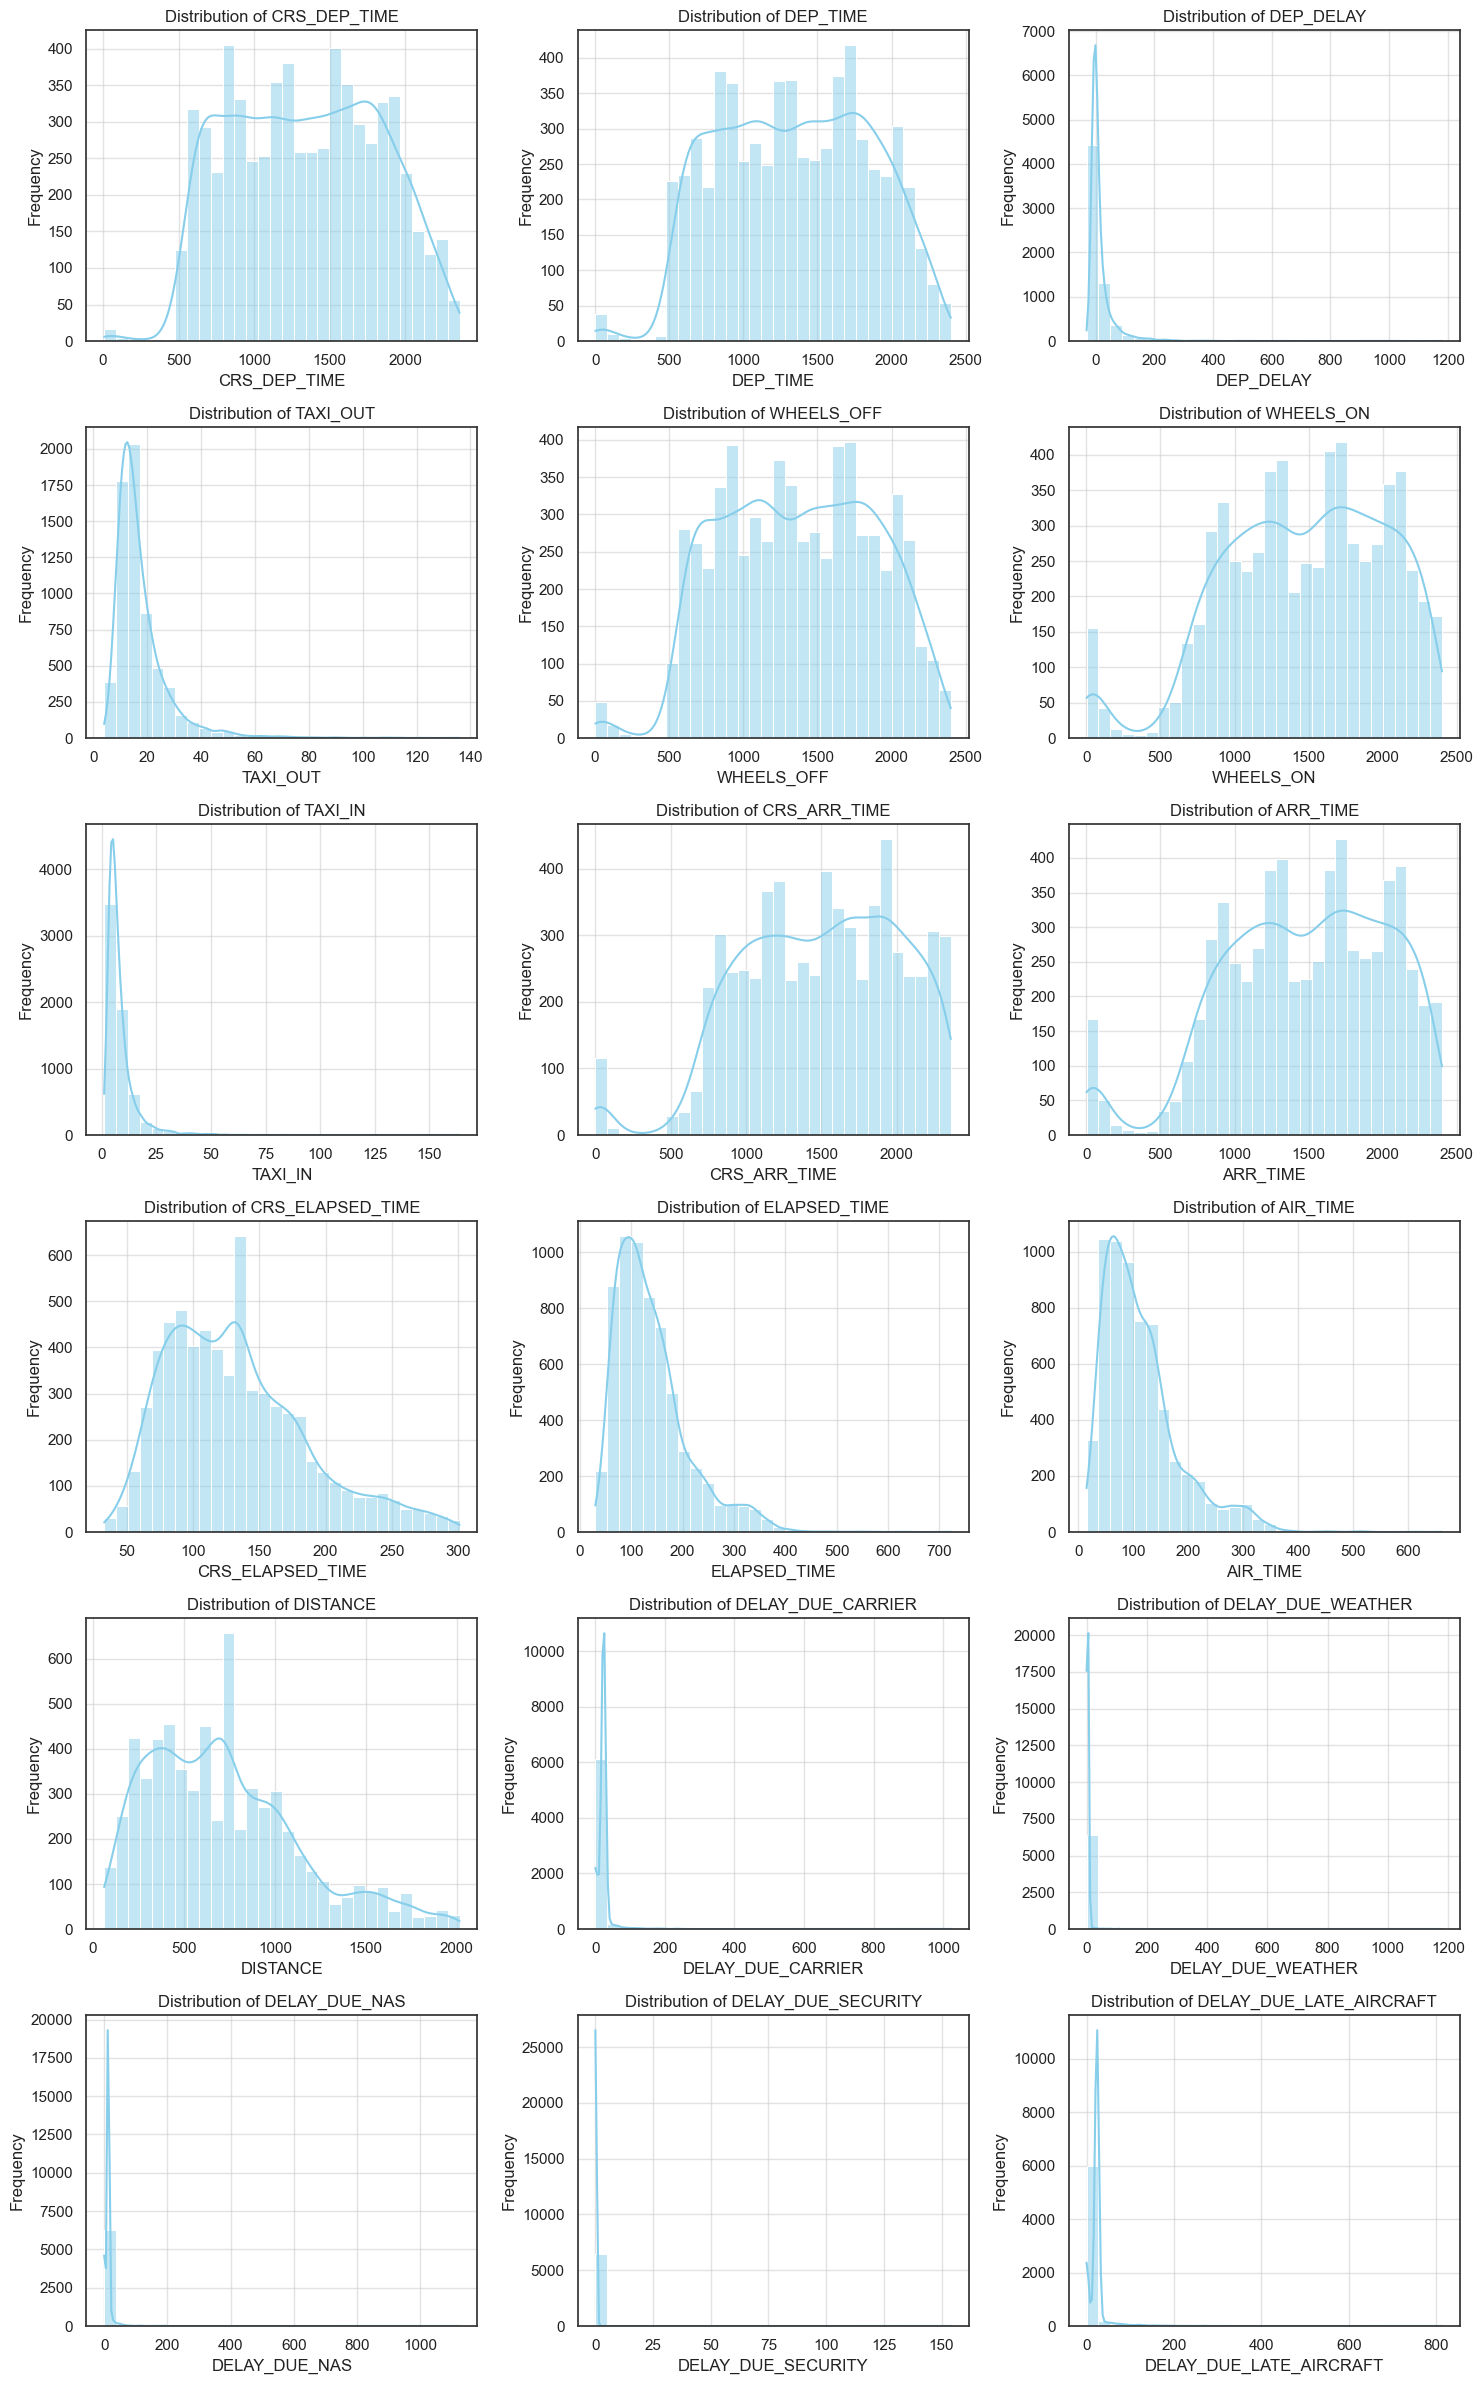

[OK] Histograms saved: eda_distributions.png
Generating correlation matrix...


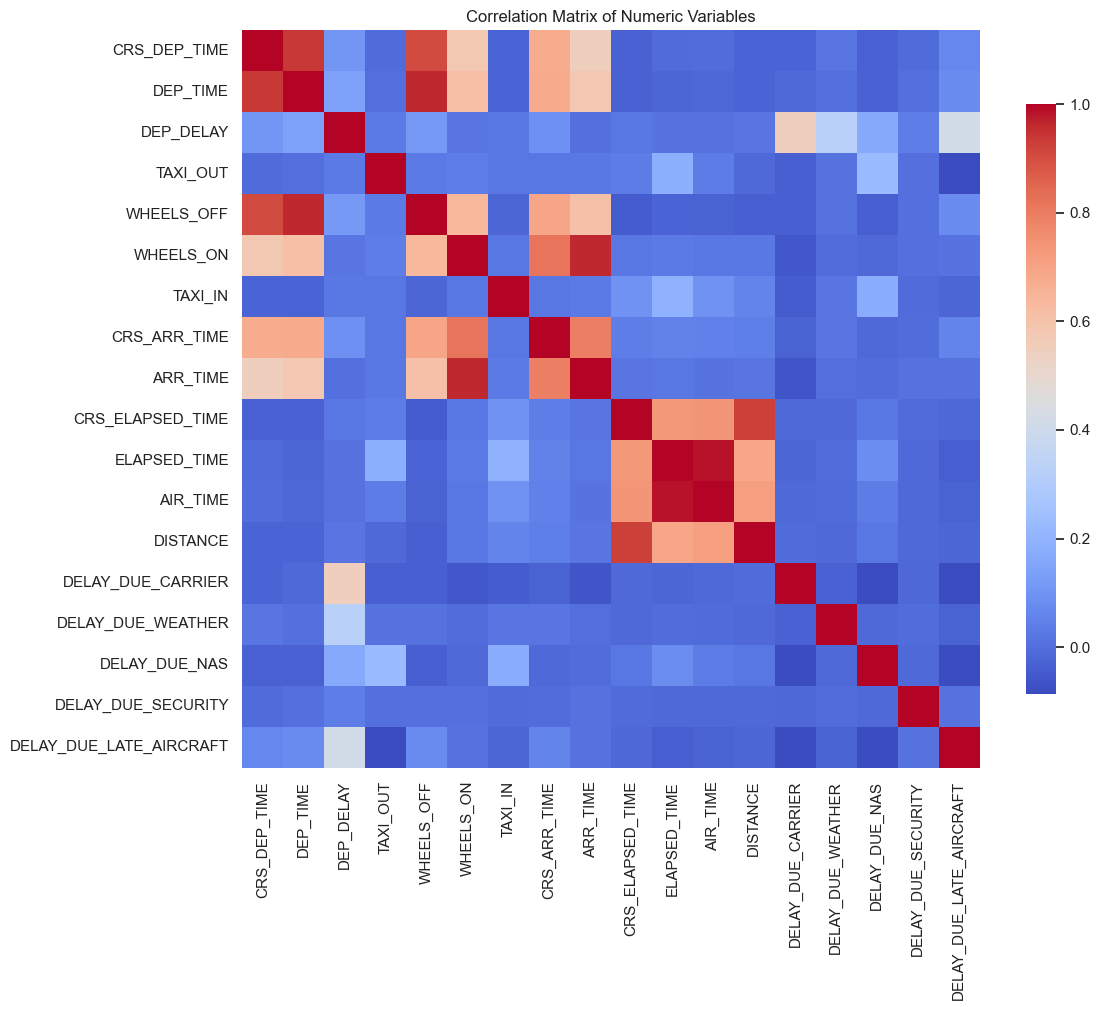

[OK] Correlation matrix saved: eda_correlation_matrix.png
Generating boxplots for 18 columns...


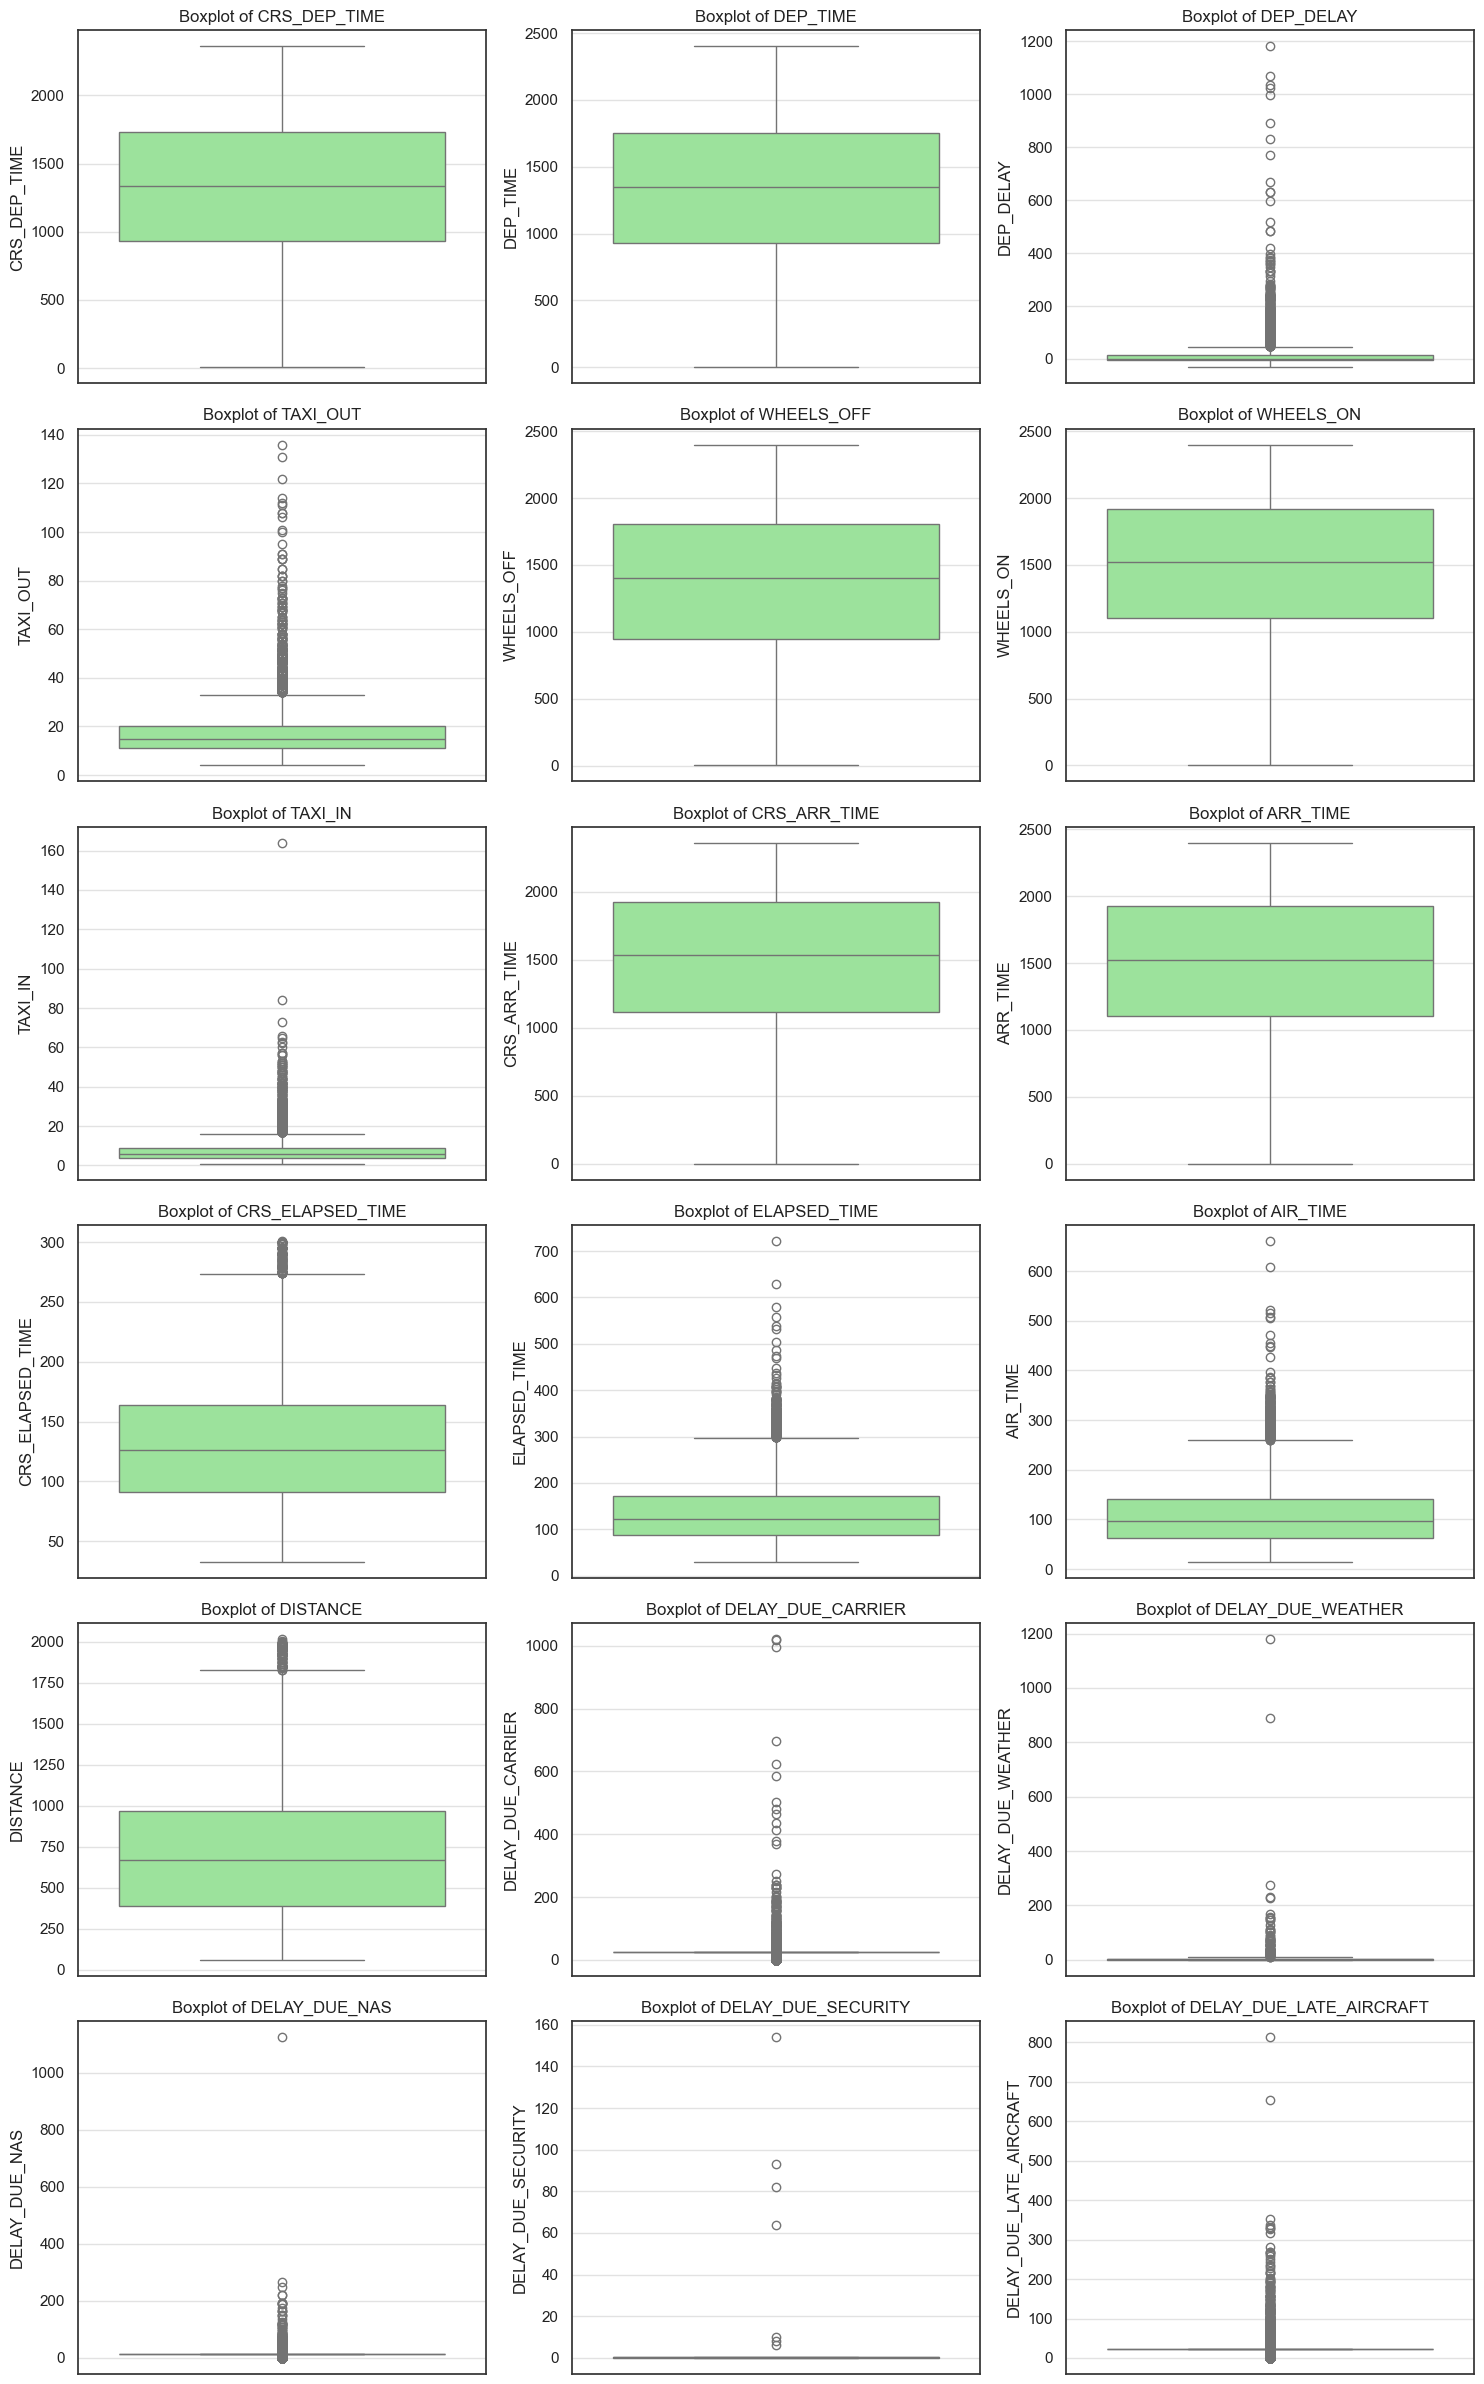

[OK] Boxplots saved: eda_boxplots.png

4. Generating target variable distribution...


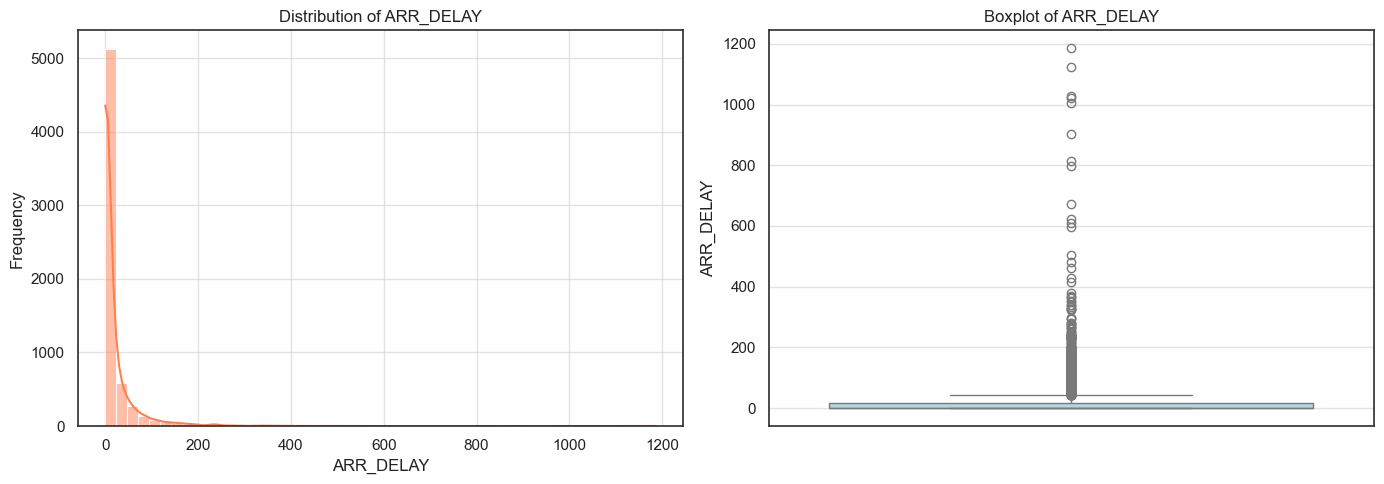

[OK] Target distribution saved: eda_target_distribution.png
EDA VISUAL (GRAFICOS BASE) CONCLUIDA!

INICIANDO EDA VISUAL AGRUPADA (DELAY_CLASS)
Generating grouped histograms for 6 columns...


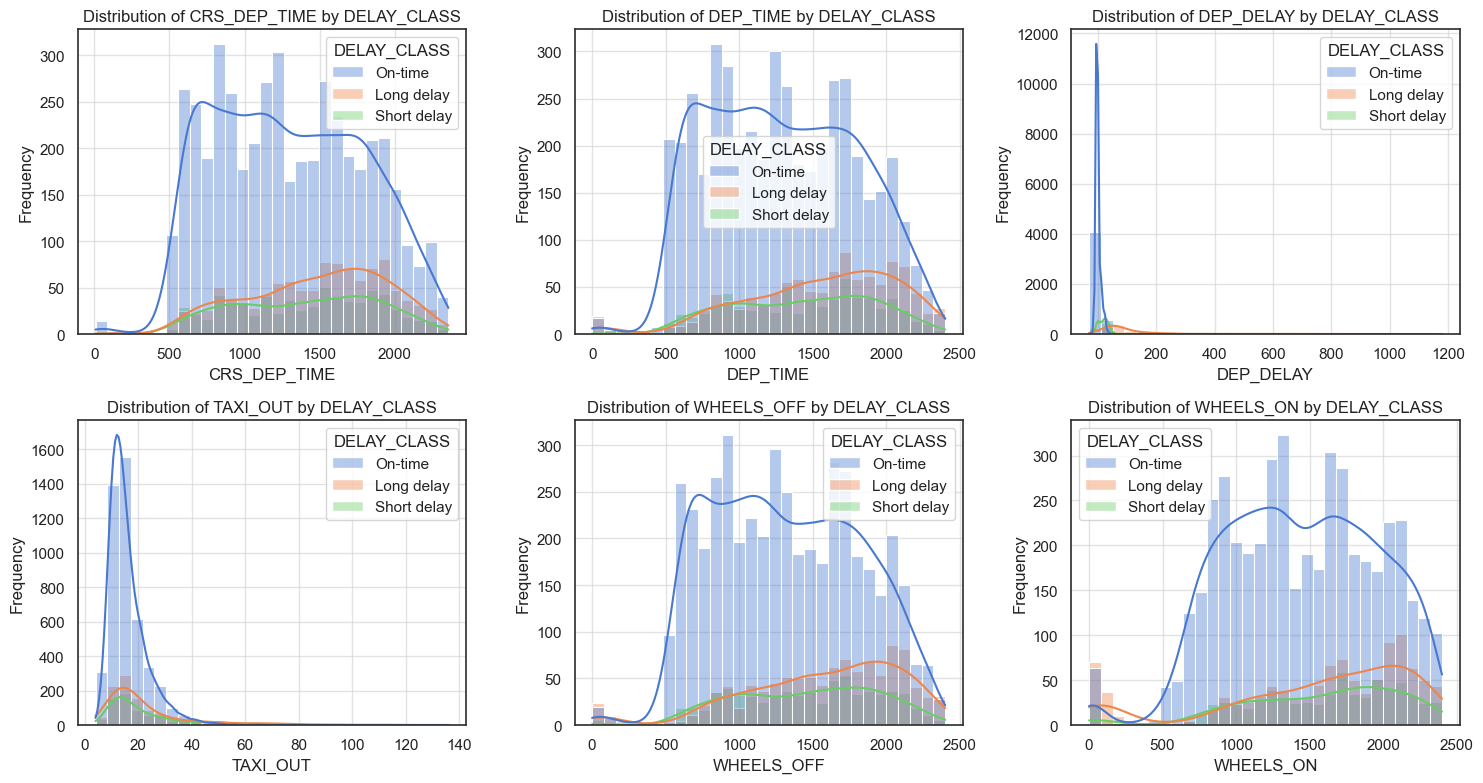

[OK] Grouped histograms saved: eda_grouped_distributions.png
Generating grouped boxplots for 6 columns...


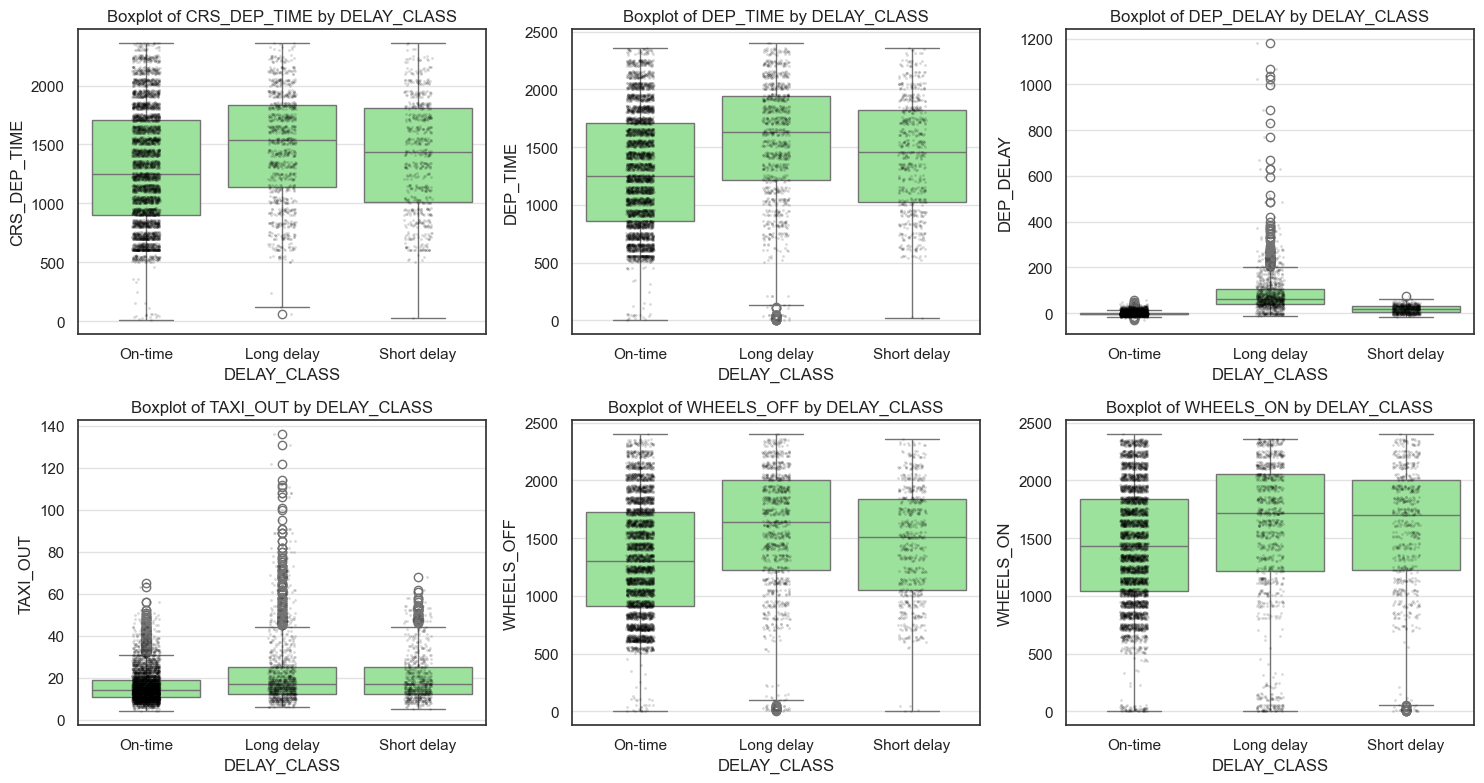

[OK] Grouped boxplots saved: eda_grouped_boxplots.png
EDA VISUAL AGRUPADA CONCLUIDA!

EDA CONCLUIDA!

Missing values total: 0
Duplicate rows: 0
Top outlier counts:
DELAY_DUE_CARRIER          1771
DELAY_DUE_LATE_AIRCRAFT    1771
DELAY_DUE_NAS              1771
ARR_DELAY                   799
DEP_DELAY                   719
dtype: int64


In [6]:
# STEP 7: Run full EDA routine
eda = FlightEDA(df_clean, target_col="ARR_DELAY", output_dir=output_dir, group_col="DELAY_CLASS")
eda_report = eda.perform_eda()

print("Missing values total:", int(eda_report["quality"]["missing_values"].sum()))
print("Duplicate rows:", int(eda_report["quality"]["duplicate_count"]))
print("Top outlier counts:")
print(eda_report["quality"]["outlier_count"].head(5))


Generating top 10 correlations heatmap...


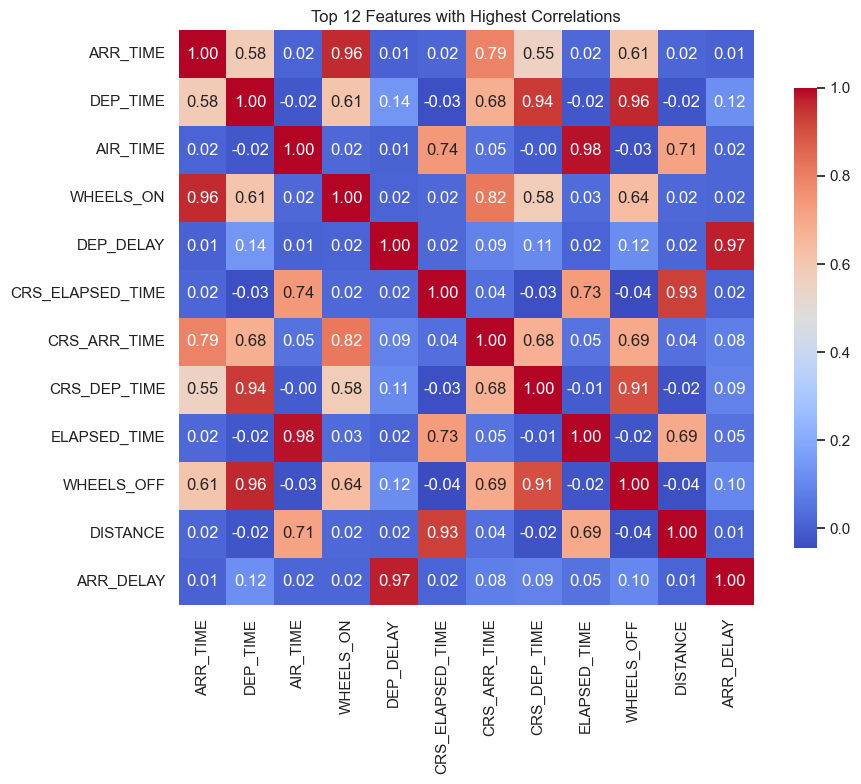

[OK] Heatmap saved: viz_heatmap_top_correlations.png


In [7]:
# STEP 10: Additional visual diagnostics
viz = DataVisualization(df_clean, output_dir=output_dir)
viz.plot_heatmap_top_correlations(top_n=10)


EXECUTANDO PCA


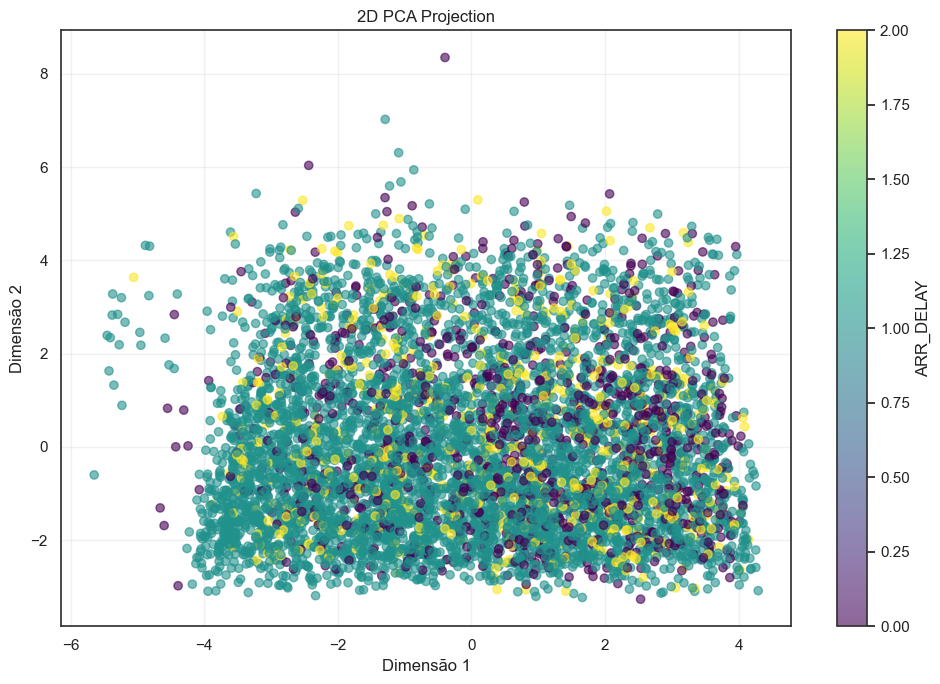


✓ PCA executado e visualizado

PCA type: <class 'numpy.ndarray'>
PCA shape: (6424, 2)


In [8]:
# STEP 8: PCA
df_clean.head(3)
pca_components = eda.run_pca(n_components=2, explained_variance_threshold=0.8)

print("PCA type:", type(pca_components))
print("PCA shape:", pca_components.shape)



EXECUTANDO UMAP / t-SNE

Aplicando UMAP...


C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


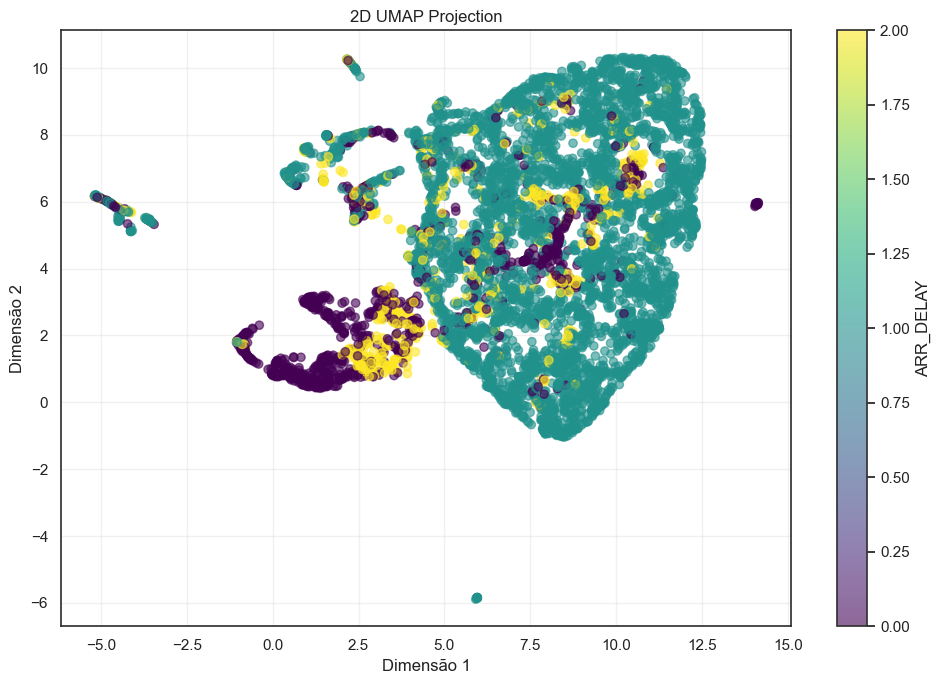


✓ UMAP executado e visualizado

UMAP/t-SNE type: <class 'numpy.ndarray'>
UMAP/t-SNE shape: (6424, 2)


In [9]:
# STEP 9: UMAP/t-SNE
umap_components = eda.run_umap_or_tsne(n_components=2, use_umap=True)

print("UMAP/t-SNE type:", type(umap_components))
print("UMAP/t-SNE shape:", umap_components.shape)


Graphs to show delay class

Generating grouped histograms for 3 columns...


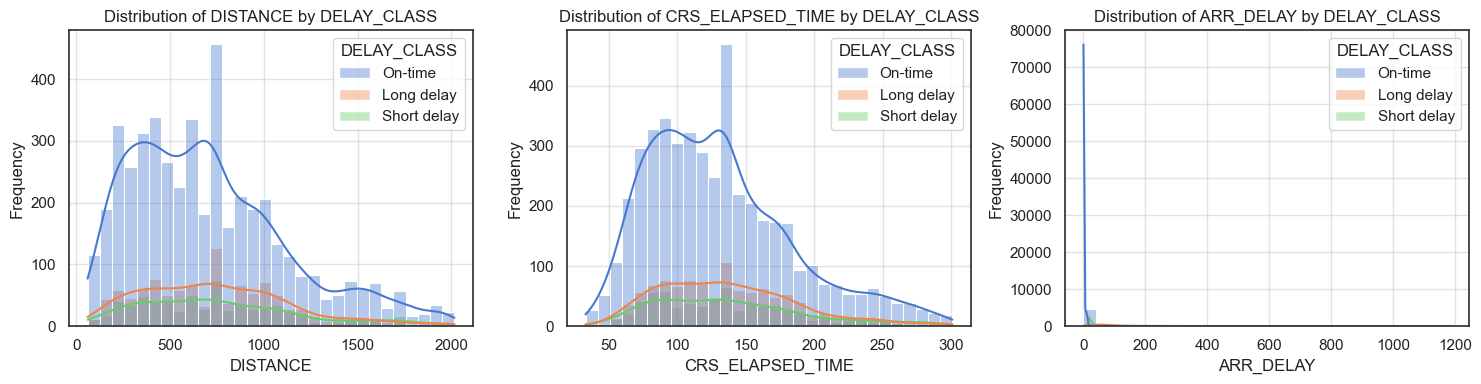

[OK] Grouped histograms saved: viz_grouped_distributions_delay_class.png
Generating grouped boxplots for 3 columns...


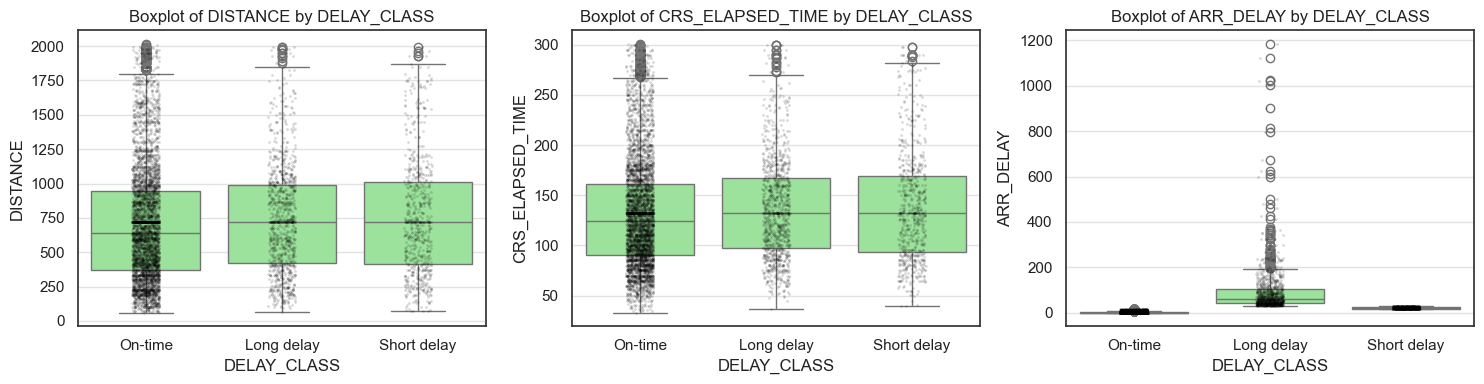

[OK] Grouped boxplots saved: viz_grouped_boxplots_delay_class.png


In [10]:
if "DELAY_CLASS" in df_clean.columns:
    focus_cols = ["DISTANCE", "CRS_ELAPSED_TIME", "PLANNED_SPEED_MPM", "ARR_DELAY"]
    viz.plot_grouped_feature_distributions(
        columns=focus_cols,
        group_col="DELAY_CLASS",
        filename="viz_grouped_distributions_delay_class.png",
    )
    viz.plot_grouped_boxplots(
        columns=focus_cols,
        group_col="DELAY_CLASS",
        filename="viz_grouped_boxplots_delay_class.png",
    )

Description of outputs of EDA:\

Below shows a list of output files derived from EDA and that can be found in the output directory for future reference.

In [11]:
generated_eda_files = sorted([p.name for p in output_dir.glob("eda_*.png")])
print("Generated EDA files:")
for name in generated_eda_files:
    print("-", name)

Generated EDA files:
- eda_boxplots.png
- eda_correlation_matrix.png
- eda_distributions.png
- eda_grouped_boxplots.png
- eda_grouped_distributions.png
- eda_pca_2d.png
- eda_target_distribution.png
- eda_umap_2d.png


## Phase 3 - Feature Engineering and Transformation

This phase converts cleaned operational fields into model-ready features.

### What is created in this step

- Temporal behavior features
- Route and interaction features
- Delay classification target (`DELAY_CLASS`)
- Encoded categorical columns
- Normalized numeric predictors


In [12]:
# Remove leakage columns
df_removed = cleaner.remove_data_leak_cols()

# STEP 3: Generate features
engineer = FlightFeatureEngineer(df_removed)
df_features = engineer.generate_features()

# STEP 4: Encode categorical features
df_features = engineer.encode_categorical()

# STEP 5: Normalize numeric features
df_features = engineer.normalize_features()

print("Features shape:", df_features.shape)
print("Total columns:", len(df_features.columns))
print("DELAY_CLASS present:", "DELAY_CLASS" in df_features.columns)
df_features.head(3)


INICIANDO FEATURE ENGINEERING

1. Processando features temporais...
   ✓ 10 features temporais criadas

2. Processando features de rota...
   ✓ 3 features de rota criadas

3. Processando features de categorização...
   ✓ 3 features de categorização criadas

4. Processando features de interação...
   ✓ 3 features de interação criadas

FEATURE ENGINEERING CONCLUÍDO!
Total de features novas: 20
Dimensão do dataset: 6424 linhas × 29 colunas

Codificando variáveis categóricas...
   ✓ DISTANCE_CAT codificada
   ✓ DURATION_CAT codificada
   ✓ SPEED_CAT codificada
   ✓ DELAY_CLASS codificada
   ✓ ROUTE codificada

Normalizando features numéricas (StandardScaler)...
   ✓ 23 features normalizadas
Features shape: (6424, 29)
Total columns: 29
DELAY_CLASS present: True


,AIRLINE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,DISTANCE,DELAY_CLASS,...,NIGHT_FLIGHT,ROUTE,ROUTE_FREQUENCY,PLANNED_SPEED_MPM,DISTANCE_CAT,DURATION_CAT,SPEED_CAT,DISTANCE_x_ELAPSED_TIME,DISTANCE_POW2,ELAPSED_TIME_POW2
0,SkyWest Airlines Inc.,OO,DEN,SUN,-0.397887,-0.286820,11.0,-0.164703,-0.385006,1,...,-0.57735,-0.775420,-1.002691,-0.402393,-0.498256,-0.934576,1.156342,-0.426862,-0.491679,-0.302679
1,United Air Lines Inc.,UA,MFE,IAH,-1.285253,-1.291176,0.0,-1.084404,-0.962400,1,...,-0.57735,0.417487,-1.002691,-0.605013,1.224455,1.070004,1.156342,-0.840302,-0.764580,-0.882324
2,Southwest Airlines Co.,WN,ABQ,SAN,-1.470980,-1.494369,0.0,-0.239780,-0.214902,1,...,-0.57735,-1.713040,-1.002691,0.136808,-0.498256,1.070004,-0.850693,-0.369522,-0.382547,-0.360697


In [13]:
# STEP 6: Intermediate checkpoint
loader.data = df_features
checkpoint_clean_path = dataset_path.parent / "checkpoint_cleaned_features.pkl"
loader.save_checkpoint(str(checkpoint_clean_path))

print("Checkpoint created:", checkpoint_clean_path.exists())
print("Checkpoint path:", checkpoint_clean_path)


Checkpoint salvo: C:\Users\Lenovo\Desktop\DataScience_IA\DataSet\checkpoint_cleaned_features.pkl
Checkpoint created: True
Checkpoint path: C:\Users\Lenovo\Desktop\DataScience_IA\DataSet\checkpoint_cleaned_features.pkl


## Phase 5 - Hypothesis Testing and Final Checkpoint

This final phase provides statistical evidence for feature differences across delay classes.

### Statistical output goals



test 1

In [14]:
# Initialize the tester with your cleaned dataframe
tester = HypothesisTester(data=df_removed, target_col='DELAY_CLASS')

# TEST SET A: Temporal Features (ANOVA)
# We want to see if the 'Hour' or 'Day of Week' significantly impacts delays
time_features = ['SCHEDULED_DEP_HOUR', 'DAY_OF_WEEK', 'MONTH']
time_anova = tester.perform_anova_test(columns=time_features)
print("--- Temporal Feature Significance ---")
display(time_anova)


KeyError: 'SCHEDULED_DEP_HOUR'

test 2

In [ ]:
# TEST SET B: Logistics/Distance (Kruskal-Wallis)
# Since Distance is often not normally distributed, we use a non-parametric test
logistic_features = ['DISTANCE', 'CRS_ELAPSED_TIME']
dist_kruskal = tester.perform_kruskal_wallis_test(columns=logistic_features)
print("\n--- Logistic Feature Significance (Non-Parametric) ---")
display(dist_kruskal)